### **2주차 프로젝트**

이번 프로젝트에서는 Upbit API를 활용해 암호화폐의 시세 데이터를 수집하고,
이를 전처리 → 데이터베이스 저장 → 시각화까지 연결하는 데이터 파이프라인 전체 흐름을 구현합니다.

과제는 **필수 과제**와 **도전 과제**로 나뉘며, 필수 과제는 반드시 제출해야 하고, 도전 과제는 선택적으로 수행하면 됩니다.

---

**[필수 과제]**
*   문제1. 종가와 시가의 차이 계산
*   문제2. 5일 이동평균선 계산 및 결측치 처리

**[도전 과제]**
*   문제3. 종가와 5일 이동평균선 시각화

### 학습 목표

- 외부 API를 통해 암호화폐 시세 데이터를 불러올 수 있다.
- 불러온 데이터를 표 형태로 정리하고 필요한 열만 추출할 수 있다.
- 이동평균선 등 기본적인 기술 지표를 계산하고 데이터베이스에 저장할 수 있다.
- 가격 변동 추이를 차트로 시각화하여 데이터 분석 과정을 한 흐름으로 경험할 수 있다.

In [1]:
!pip install pyupbit

In [2]:
!apt-get install -y fonts-nanum
!fc-cache -fv

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [4]:
import pandas as pd
import pyupbit
import sqlite3
import time
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import dates as mdates

import warnings
warnings.filterwarnings('ignore')

fm._load_fontmanager(try_read_cache=False)
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

In [5]:
# 데이터 수집
class UpbitDataCollector:
  def __init__(self):
    self.supported_tickers = None

  # KRW 티커 조회 함수
  def get_krw_tickers(self):
    try:
      tickers = pyupbit.get_tickers(fiat='KRW')
      self.supported_tickers = tickers
      return tickers
    except Exception as e:
      print(f'티커 조회 오류')
      self.supported_tickers = []
      return []

  # 현재가 조회 함수
  def get_current_prices(self, tickers):
    try:
      # 입력을 리스트로 통일
      if isinstance(tickers, str):
        tickers = [tickers]

      result = pyupbit.get_current_price(tickers)

      if isinstance(result, (int, float)):
        result = {tickers[0]: result}

      return pd.DataFrame(
          list(result.items()),
          columns=['ticker', 'curenct_price']
      )

    except Exception as e:
      print(f'현재가 조회 실패: {e}')
      return pd.DataFrame(columns=['ticker', 'current_price'])  # 빈 DF 반환


  # OHLCV 데이터 조회
  # Open: 시가 / High: 고가 / Low: 저가 / Close: 종가 / Volumne: 거래량
  def get_ohlcv_data(self, ticker, interval='day', count=30):
    '''단일 코인 OHLCV 조회'''
    try:
      df = pyupbit.get_ohlcv(ticker, interval=interval, count=count)
      if df is not None:
        df['ticker'] = ticker
        df.reset_index(inplace=True)
      return df

    except Exception as e:
      print(f'{ticker} OHLCV 데이터 조회 오류: {e}')
      return None


  def get_multiple_ohlcv(self, tickers, interval='day', count=30, delay=0.1):
    '''여러 코인 OHLCV 일괄 조회'''
    all_data = []
    for ticker in tickers:
      print(f'{ticker} 데이터 수집 중...')
      data = self.get_ohlcv_data(ticker, interval, count)

      if data is not None:
        all_data.append(data)
      time.sleep(delay)

    if all_data:
      return pd.concat(all_data, ignore_index=True)
    return pd.DataFrame()

In [6]:
collector = UpbitDataCollector()
print(collector.get_krw_tickers())

['KRW-WAXP', 'KRW-CARV', 'KRW-LSK', 'KRW-0G', 'KRW-WIF', 'KRW-BORA', 'KRW-PUNDIX', 'KRW-PROS', 'KRW-USD1', 'KRW-BAT', 'KRW-HUNT', 'KRW-PENGU', 'KRW-FIL', 'KRW-BEAM', 'KRW-DOOD', 'KRW-WAVES', 'KRW-USDC', 'KRW-MOVE', 'KRW-TREE', 'KRW-USDE', 'KRW-AERGO', 'KRW-WET', 'KRW-USDT', 'KRW-USDS', 'KRW-2Z', 'KRW-BOUNTY', 'KRW-KAITO', 'KRW-LPT', 'KRW-BLAST', 'KRW-ETHFI', 'KRW-DKA', 'KRW-ANKR', 'KRW-ALGO', 'KRW-SHIB', 'KRW-UNI', 'KRW-BIO', 'KRW-WLFI', 'KRW-TOKAMAK', 'KRW-SKY', 'KRW-CYBER', 'KRW-SKR', 'KRW-DOGE', 'KRW-WLD', 'KRW-PEPE', 'KRW-HBAR', 'KRW-BCH', 'KRW-NEWT', 'KRW-SEI', 'KRW-BONK', 'KRW-JST', 'KRW-AAVE', 'KRW-JTO', 'KRW-JUP', 'KRW-PIEVERSE', 'KRW-ALT', 'KRW-B3', 'KRW-LAYER', 'KRW-TRX', 'KRW-POWR', 'KRW-ATOM', 'KRW-ARKM', 'KRW-CRO', 'KRW-NXPC', 'KRW-A', 'KRW-TRUMP', 'KRW-F', 'KRW-G', 'KRW-CELO', 'KRW-AERO', 'KRW-CTC', 'KRW-ANIME', 'KRW-APT', 'KRW-MOCA', 'KRW-API3', 'KRW-AHT', 'KRW-EGLD', 'KRW-BLEND', 'KRW-ERA', 'KRW-FF', 'KRW-PLUME', 'KRW-ESP', 'KRW-CC', 'KRW-NEO', 'KRW-ETC', 'KRW-IOTA', 'K

# 데이터 전처리

## [필수 과제] 문제1: 종가와 시가의 차이 계산
종가와 시가의 차이를 계산하여 price_change 컬럼에 저장하시오


### 📌 구현 단계
1. **`price_change` 컬럼 생성**  
   - `close`(종가) - `open`(시가)의 차이를 계산하여 새로운 컬럼으로 추가한다.
2. **`price_change_pct` 컬럼 계산**
   - `price_change / open * 100`으로 변동률(%)을 계산한다.
3. **`high_low_diff` 컬럼 추가**
   - `high - low`를 계산하여 일중 변동폭을 나타내는 컬럼을 만든다.



<details>
<summary>💡 구현 힌트 (펼쳐보기)</summary>

- DataFrame의 컬럼 간 계산은 바로 가능합니다.
  ```python
  df['price_change'] = df['close'] - df['open']
  df['price_change_pct'] = (df['price_change'] / df['open']) * 100

- 추가 컬럼은 반드시 원본 데이터프레임에 병합합니다.
</details>  

<br>  

---
<br>  
  
## [필수 과제] 문제2: 5일 이동평균선 계산 및 결측치 처리
5일 이동평균선 값을 계산하여 'ma5' 컬럼에 저장하고 결측치를 처리하시오


### 📌 구현 단계
1. **이동평균선(`ma5`) 계산**  
   - 각 코인(`ticker`)별로 `close` 기준 5일 이동평균을 계산한다.
2. **`결측치 처리**
   - 이동평균 계산 초기에 생기는 NaN을 `close` 값으로 대체한다.
3. **전처리 완료 후 컬럼 순서 정리**
   - `ma5` 컬럼을 포함하여 최종 순서를 정돈한다.



<details>
<summary>💡 구현 힌트 (펼쳐보기)</summary>

- 이동평균은 **rolling() 메서드**를 활용할 수 있습니다.
- 티커별로 계산하려면 **조건 필터링(mask)** 또는 **groupby()** 로 나누어 수행합니다.
- 결측치 보정 시에는 **fillna()** 메서드를 활용해 보세요.
- 이동평균을 추가한 후에는 **데이터프레임 컬럼 순서**를 다시 맞춰줍니다.

In [7]:
# 데이터 전처리
def preprocess_data(df):
  # 날짜 컬럼명 정리
  df = df.rename(columns={'index': 'date'})
  df['date'] = pd.to_datetime(df['date'])

  # 문제1: 가격 차이 계산
  df['price_change']     = df['close'] - df['open']               # 종가 - 시가
  df['price_change_pct'] = df['price_change'] / df['open'] * 100  # 변동률(%)
  df['high_low_diff']    = df['high'] - df['low']                 # 일중 변동폭

  # 문제2: 5일 이동평균선 계산 및 결측치 처리
  # rolling위해 코인 별 날짜 순서 정렬
  df = df.sort_values(['ticker', 'date']).reset_index(drop=True)

  df['ma5'] = (
      df.groupby('ticker')['close'].transform(lambda x: x.rolling(window=5).mean())
  )

  # 결측치 처리: 초기 NaN을 close 값으로 대체
  df['ma5'] = df['ma5'].fillna(df['close'])

  # 컬럼 순서 정리
  columns_order = [
      'date', 'ticker',
      'open', 'high', 'low', 'close', 'volume',
      'price_change', 'price_change_pct', 'high_low_diff', 'ma5'
  ]

  return df[columns_order]

In [8]:
collector = UpbitDataCollector()
tickers = ['KRW-BTC', 'KRW-ETH', 'KRW-XRP']
raw_df = collector.get_multiple_ohlcv(tickers, interval='day', count=30)

print('\n[1] 원본데이터 (head)')
raw_df.head()

KRW-BTC 데이터 수집 중...
KRW-ETH 데이터 수집 중...
KRW-XRP 데이터 수집 중...

[1] 원본데이터 (head)


,index,open,high,low,close,volume,value,ticker
0,2026-04-11 09:00:00,108308000.0,109384000.0,107980000.0,108567000.0,847.470411,9.200150e+10,KRW-BTC
1,2026-04-12 09:00:00,108567000.0,108765000.0,105443000.0,105700000.0,1365.156360,1.455590e+11,KRW-BTC
2,2026-04-13 09:00:00,105732000.0,110276000.0,105438000.0,109806000.0,1781.799608,1.920809e+11,KRW-BTC
3,2026-04-14 09:00:00,109804000.0,111996000.0,109200000.0,109875000.0,1946.422133,2.146009e+11,KRW-BTC
4,2026-04-15 09:00:00,109870000.0,111016000.0,109020000.0,110456000.0,1297.587667,1.426778e+11,KRW-BTC


In [9]:
df = preprocess_data(raw_df)
print('\n[2] 전처리 완료 (head)')
df.head()


[2] 전처리 완료 (head)


,date,ticker,open,high,low,close,volume,price_change,price_change_pct,high_low_diff,ma5
0,2026-04-11 09:00:00,KRW-BTC,108308000.0,109384000.0,107980000.0,108567000.0,847.470411,259000.0,0.239133,1404000.0,108567000.0
1,2026-04-12 09:00:00,KRW-BTC,108567000.0,108765000.0,105443000.0,105700000.0,1365.156360,-2867000.0,-2.640766,3322000.0,105700000.0
2,2026-04-13 09:00:00,KRW-BTC,105732000.0,110276000.0,105438000.0,109806000.0,1781.799608,4074000.0,3.853138,4838000.0,109806000.0
3,2026-04-14 09:00:00,KRW-BTC,109804000.0,111996000.0,109200000.0,109875000.0,1946.422133,71000.0,0.064661,2796000.0,109875000.0
4,2026-04-15 09:00:00,KRW-BTC,109870000.0,111016000.0,109020000.0,110456000.0,1297.587667,586000.0,0.533358,1996000.0,108880800.0


In [10]:
# 데이터베이스 저장
def create_database():
  '''SQLite 데이터베이스 생성 함수'''
  conn = sqlite3.connect('crypto_data.db')
  cursor = conn.cursor()

  return conn


def save_to_database(df):
  '''데이터베이스에 데이터 저장 함수'''
  print('=== 데이터베이스 저장 시작 ===')

  conn = create_database()

  # 데이터 저장용 DF 준비
  db_df = df[[
      'date', 'ticker',
      'open', 'high', 'low', 'close', 'volume',
      'price_change', 'price_change_pct', 'high_low_diff', 'ma5'
    ]].copy()

  # 데이터베이스에 저장
  db_df.to_sql('crypto_ohlcv', conn, if_exists='replace', index=False)

  # 저장된 데이터 확인
  cursor = conn.cursor()
  cursor.execute('SELECT COUNT(*) FROM crypto_ohlcv')
  count = cursor.fetchone()[0]

  print(f'데이터베이스에 {count}개 레코드 저장 완료')

  conn.close()
  return count


def load_from_database():
  '''데이터베이스에서 데이터 로드 함수'''
  conn = sqlite3.connect('crypto_data.db')

  query = 'SELECT * FROM crypto_ohlcv ORDER BY date, ticker'
  df = pd.read_sql_query(query, conn)

  conn.close()
  return df

In [11]:
create_database()
save_to_database(df)

=== 데이터베이스 저장 시작 ===
데이터베이스에 90개 레코드 저장 완료


90

In [12]:
load_from_database()

,date,ticker,open,high,low,close,volume,price_change,price_change_pct,high_low_diff,ma5
0,2026-04-11 09:00:00,KRW-BTC,108308000.0,109384000.0,107980000.0,108567000.0,8.474704e+02,259000.0,0.239133,1404000.0,108567000.0
1,2026-04-11 09:00:00,KRW-ETH,3335000.0,3451000.0,3316000.0,3392000.0,2.756234e+04,57000.0,1.709145,135000.0,3392000.0
2,2026-04-11 09:00:00,KRW-XRP,2013.0,2037.0,1997.0,2014.0,4.044674e+07,1.0,0.049677,40.0,2014.0
3,2026-04-12 09:00:00,KRW-BTC,108567000.0,108765000.0,105443000.0,105700000.0,1.365156e+03,-2867000.0,-2.640766,3322000.0,105700000.0
4,2026-04-12 09:00:00,KRW-ETH,3395000.0,3402000.0,3250000.0,3276000.0,3.753821e+04,-119000.0,-3.505155,152000.0,3276000.0
...,...,...,...,...,...,...,...,...,...,...,...
85,2026-05-09 09:00:00,KRW-ETH,3399000.0,3441000.0,3392000.0,3428000.0,1.299218e+04,29000.0,0.853192,49000.0,3429600.0
86,2026-05-09 09:00:00,KRW-XRP,2087.0,2115.0,2083.0,2092.0,4.624579e+07,5.0,0.239578,32.0,2080.4
87,2026-05-10 09:00:00,KRW-BTC,118992000.0,119216000.0,118887000.0,119182000.0,3.334652e+02,190000.0,0.159675,329000.0,118715200.0
88,2026-05-10 09:00:00,KRW-ETH,3429000.0,3435000.0,3415000.0,3423000.0,6.607244e+03,-6000.0,-0.174978,20000.0,3415600.0


In [13]:
# 시각화
def visualize(df):
  df['date'] = pd.to_datetime(df['date'])
  tickers = df['ticker'].unique()

  fig, axes = plt.subplots(
      len(tickers), 1,
      figsize=(12, 4.5* len(tickers)),
      constrained_layout = True
  )
  if len(tickers) == 1:
    axes = [axes]

  for ax, ticker in zip(axes, tickers):
    sub = df[df['ticker'] == ticker].sort_values('date')

    ax.plot(sub['date'], sub['close'], label='종가(Close)', linewidth=2)
    ax.plot(sub['date'], sub['ma5'],   label='5일 이동평균(MA5)',
            linewidth=2, linestyle='--')

    ax.set_title(f'{ticker} - 종가 vs 5일 이동평균선', fontsize=14)
    ax.set_xlabel('날짜')
    ax.set_ylabel('가격 (KRW)')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('crypto_chart.png', dpi=120)
plt.show()

<Figure size 640x480 with 0 Axes>

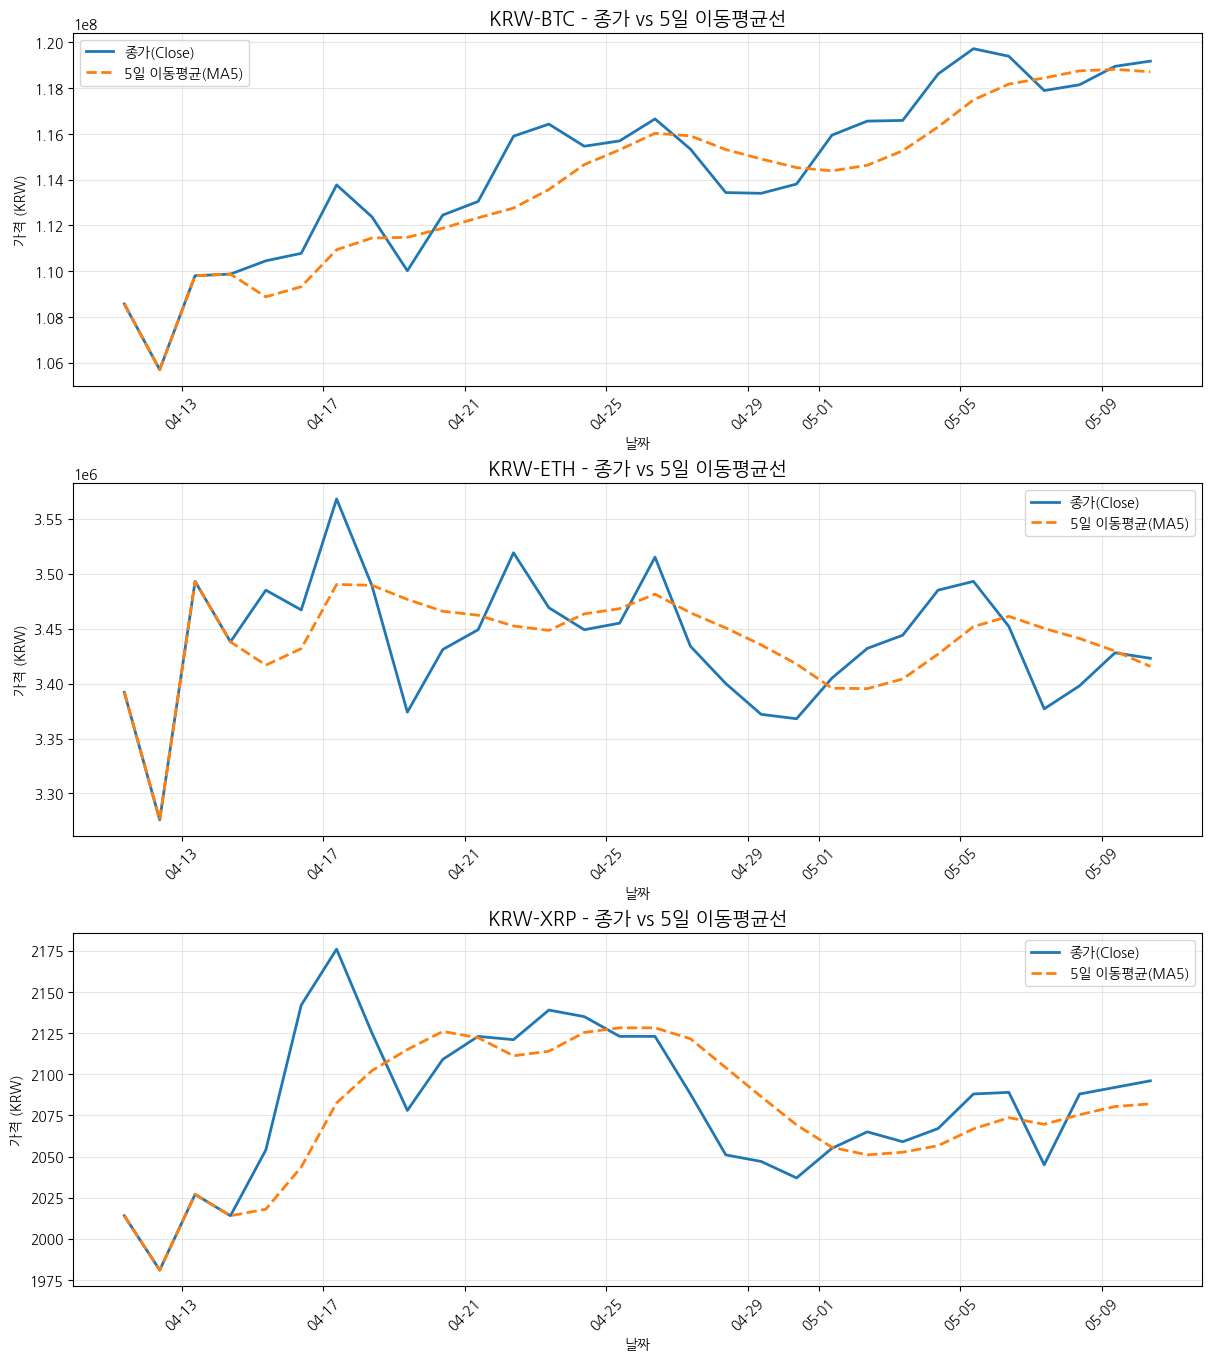

In [14]:
visualize(df)